<a href="https://colab.research.google.com/github/LeruaValero/projects_openbio/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%E2%84%962_%D0%9B%D0%BE%D0%B3%D0%B8%D0%BD%D0%BE%D0%B2%D0%B0%D0%92%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание №2
Формулировка:


Для данных из статьи Sandra Oliveira et al., Genome-wide variation in the Angolan Namib Desert reveals unique pre-Bantu ancestry.Sci. Adv.9,eadh3822(2023). DOI: 10.1126/sciadv.adh3822 визуализировать результаты PCA преобразования и попробовать на основании имеющихся метаданных с описанием образцов из статьи понять, с чем могут соотносится полученные в ходе преобразования компоненты.

Данные для выполнения задачи выложены вот тут - https://drive.google.com/drive/folders/1ksa_r-T0t3tzUyWSBtkB-q6Saq7jExZ1?usp=sharing



Программа минимум:

— Подготовьте датасет для построения PCA преобразования.

— Провести PCA преобразование данных.

— Подсчитать вклад каждой компоненты.

— Визуализировать результаты PCA преобразования с выделением на графике групп образцов принадлежащих одной популяции.



Дополнение:

— Найти в дополнительных материалах статьи метаданные использованных образцов.

— Подсчитайте корреляции между значениями главных компонент и значениями метапараметров.

— (*) Объясняют ли координаты сбора образца больше 10% дисперсии между индивидами ?

— (*) Постройте графики не только для первых двух главных компонент.

— (*) Вы обнаружили интересный эффект на основании анализа значений 4-ой главной компоненты. Можно ли считать такой результат менее надёжным по сравнению со случаем если бы такой результат получился при анализе значений 1 компоненты? Обоснуйте свой ответ.





Результат должен быть оформлен в виде тетрадки в google colab, где выводы подкреплены кодом.

Не забудьте открыть доступ к тетрадке (в режиме комментатора), чтобы задание можно было проверить.



Ссылки на задание присылайте через getcourse.



Подсказки:

— в данной статье опять приводятся значения координат единые для всех индивидов одной популяции

— так как в статье используются как данные, полученные авторами статьи, так и публичные данные то их метапараметры могут быть разнесены по разным таблицам.

— Популяции из Анголы содержат префикс “Angola” в названии

Подгрузим гугл-диск.

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Описание и загрузка данных

Основным условием для эффективного использования PCA является использование датасета без линейного связанных признаков.
У нас набор SNP после проведения операции LD pruning.   

*(Неравновесие по сцеплению(Linkage disequilibrium (LD) ) - это неслучайное распределение частот аллелей разных локусов. Обычно связано с близким расположением генетических маркеров(SNP, indel) друг относительно друга на хромосоме.)*

*(Single Nucleotide Polymorphism. Изменение одного нуклеотида (A, T, G или C) в определённой точке молекулы ДНК. Этот термин широко используется в генетических и геномиковых исследованиях для изучения связи генетических вариантов с чертами или заболеваниями.)*

Датасет состоит из 208 индивидов принадлежащих к к девяти этническим группам из Анголо-Намибии и прилегающих районов, которые вели добывающий пищу образ жизни (Сюнь), странствующий (Квепе, Квиси, Тва и Тжимба), скотоводческий (Химба и Кувале) и агропастырский (Овимбунду и Ньянека) образ жизни.  


*ped.* файл нужно переформатировать, убрать лишние записи, связанные с идентификатором матери, отца, фенотипом и полом. А первые два столбца объединить вместе, вставив между ними "_", чтобы идентификатор образца содержал в себя имя популяции. Для этих целей используем готовый ниже скрипт.

In [ ]:
# Транспонируем ped файл
import numpy
import os,sys

snpsBySample = dict()

tableFileHandle = open("/content/drive/MyDrive/Данные для коллаба/africa_UNPrem.LD_pruned.ped","r")

ango_data_array = []
name_of_individuals = []

for line in tableFileHandle:
  line = line[:-1]

  arrLine = line.split("\t")

  familyName = arrLine[0]
  sampleName = arrLine[1]

  currFamilySample = familyName + "_" + sampleName
# Загружаем ped файл в память
  for index in range(6,len(arrLine)):
    currval = arrLine[index]
    arrCurrVal = currval.split(" ")
    currval_1 = int(arrCurrVal[0])
    currval_2 = int(arrCurrVal[1])
    if currFamilySample in snpsBySample.keys():
      snpsBySample[currFamilySample].append(currval_1)
      snpsBySample[currFamilySample].append(currval_2)
    else:
      snpsBySample[currFamilySample] = list()
      snpsBySample[currFamilySample].append(currval_1)
      snpsBySample[currFamilySample].append(currval_2)

arrFamilySamples = snpsBySample.keys()
isNotFirst = 0
for currFamilySample in arrFamilySamples:
  name_of_individuals.append(currFamilySample)

lastIndex = 0
for currFamilySample in arrFamilySamples:
  arrSnps = snpsBySample[currFamilySample]
  lastIndex = len(arrSnps)
  break
for index in range(0,lastIndex):
  currLineArr = []
  for currFamilySample in arrFamilySamples:
    arrSnps = snpsBySample[currFamilySample]
    currValSNP = arrSnps[index]
    currLineArr.append(currValSNP)
  ango_data_array.append(currLineArr)

tableFileHandle.close()

In [ ]:
import pandas as pd
#Загружаем данные в pandas DataFrame
ango_data = pd.DataFrame(data = ango_data_array, columns=name_of_individuals)

ango_data

,AngolaKwisi_AngH01,AngolaHimba_AngH03,AngolaKuvale_AngH05,AngolaKwepe_AngH09,AngolaKwepe_AngH10,AngolaKwepe_AngH13,AngolaKwepe_AngH14,AngolaKwisi_AngH15,AngolaTwa_AngH16,AngolaTwa_AngH19,...,JewLibyan_LibyanJew1605,JewEthiopian_EthiopianJew1831,JewTunisian_TunisianJew1511,Tunisian_Tunisian20D1,Tunisian_Tunisian20B4,Egyptian_Egypt7AQ172,JewMoroccan_MoroccanJew4683,JewLibyan_LibyanJew1639,JewLibyan_LibyanJew1659,Egyptian_Egypt22TD21
0,1,2,1,1,1,1,1,1,1,2,...,1,1,1,1,1,2,2,2,2,1
1,2,2,2,1,2,1,1,2,2,2,...,1,1,2,2,2,2,2,2,2,1
2,2,1,2,2,2,2,2,2,2,2,...,1,1,1,1,1,2,2,1,2,2
3,2,1,2,2,2,2,2,2,2,2,...,2,2,2,2,1,2,2,2,2,2
4,2,2,1,2,2,2,1,1,2,1,...,1,1,1,1,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302647,2,0,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
302648,2,2,2,2,2,2,2,2,1,2,...,2,2,2,2,2,2,2,2,2,2
302649,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
302650,1,2,2,2,2,2,2,2,2,2,...,1,2,2,2,2,2,2,1,2,2


В строках идут SNP. Причём каждому SNP соответствует две строки. В столбцах индивиды. Причём имя индивида устроено следующим образом:<название популяции>_<идентификатор_индивида>. В ячейках таблицы находится информация об аллеле. Может быть два значения - 1 или 2. 1 для минорного аллеля. 2 - для мажорного.  

*Мажорный аллель — это наиболее широко распространённый в популяции аллель, который характеризуется неизмененной функциональной активностью. Обычно частота встречаемости выше 0,5; часто около 0,9.*

*Минорный аллель — это аллель, который встречается редко и обусловливает некоторые физико-химические вариации в активности кодируемого белка.*

Дополнительно имеется map файл с описанием SNP.

In [ ]:
import pandas as pd
ango_data_map = pd.read_csv("/content/drive/MyDrive/Данные для коллаба/africa_UNPrem.LD_pruned.map",sep="\t",header=None) #загружаем map файл
ango_data_map

,0,1,2,3
0,1,1_752566,0.007526,752566
1,1,1_842013,0.008420,842013
2,1,1_891021,0.008910,891021
3,1,1_903426,0.009034,903426
4,1,1_949654,0.009497,949654
...,...,...,...,...
350714,22,22_51175626,0.511756,51175626
350715,22,22_51176347,0.511763,51176347
350716,22,22_51177526,0.511775,51177526
350717,22,22_51185363,0.511854,51185363


Каждая строка соответствует SNP  
Первый столбец - номер хромосомы. Второй столбец - идентификатор SNP. Третий столбец - генетическая дистанция в cM, Четвертый столбец - позиция внутри хромосомы.  
Для нашего анализа map файл не будем использовать.

## (*) Доп задание
— Найти в дополнительных материалах статьи метаданные использованных образцов.— Подсчитайте корреляции между значениями главных компонент и значениями метапараметров.

Загрузим метаданные и объеденим таблицы.

In [ ]:
ango_data_meta = pd.read_excel("/content/drive/MyDrive/Данные для коллаба/adh3822_Tables S1 to S9.xlsx", sheet_name='Table S1')
ango_data_meta

,"Table S1 – Studied populations, their languages, subsistence strategies, and geographic locations.",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population,Code,Language,Language group,Subsistence strategy,Sample size,Sample size (excluding relatives),Country,Latitude,Longitude
2,Ovimbundu,OVI,Umbundu,West Bantu,Agropastoralist,6,6,Angola,-15.31,13.99
3,Nyaneka,NYA,Nyaneka,West Bantu,Agropastoralist,14,14,Angola,-11.89,14.92
4,Kuvale,KUV,Kuvale,West Bantu,Pastoralist,45,41,Angola,-15.64,13.07
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-14.58,13.19
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-15.76,12.95
7,Himba,HIMA,Herero,West Bantu,Pastoralist,24,22,Angola,-16.98,12.58
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-16.69,12.85
9,Tjimba,TJI,Herero,West Bantu,Peripatetic,15,12,Angola,-17.06,12.65


In [ ]:
ango_data_meta.columns = ango_data_meta.iloc[1]
ango_data_meta.drop(ango_data_meta.index[1], inplace = True)
ango_data_meta.reset_index(drop=True)

1,Population,Code,Language,Language group,Subsistence strategy,Sample size,Sample size (excluding relatives),Country,Latitude,Longitude
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ovimbundu,OVI,Umbundu,West Bantu,Agropastoralist,6,6,Angola,-15.31,13.99
2,Nyaneka,NYA,Nyaneka,West Bantu,Agropastoralist,14,14,Angola,-11.89,14.92
3,Kuvale,KUV,Kuvale,West Bantu,Pastoralist,45,41,Angola,-15.64,13.07
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-14.58,13.19
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-15.76,12.95
6,Himba,HIMA,Herero,West Bantu,Pastoralist,24,22,Angola,-16.98,12.58
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-16.69,12.85
8,Tjimba,TJI,Herero,West Bantu,Peripatetic,15,12,Angola,-17.06,12.65
9,Twa,TWA,Kuvale,Bantu,Peripatetic,17,14,Angola,-15.85,12.12


Я вручную в файле доп.метаданных .xlsx заменила "S" на минус - в самом низу обясняю зачем.

In [ ]:
ango_data_meta.drop(index=0, inplace = True)
ango_data_meta.reset_index(drop=True, inplace = True)
ango_data_meta

1,Population,Code,Language,Language group,Subsistence strategy,Sample size,Sample size (excluding relatives),Country,Latitude,Longitude
0,Ovimbundu,OVI,Umbundu,West Bantu,Agropastoralist,6,6,Angola,-15.31,13.99
1,Nyaneka,NYA,Nyaneka,West Bantu,Agropastoralist,14,14,Angola,-11.89,14.92
2,Kuvale,KUV,Kuvale,West Bantu,Pastoralist,45,41,Angola,-15.64,13.07
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-14.58,13.19
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-15.76,12.95
5,Himba,HIMA,Herero,West Bantu,Pastoralist,24,22,Angola,-16.98,12.58
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-16.69,12.85
7,Tjimba,TJI,Herero,West Bantu,Peripatetic,15,12,Angola,-17.06,12.65
8,Twa,TWA,Kuvale,Bantu,Peripatetic,17,14,Angola,-15.85,12.12
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola,-16.65,13.44


In [ ]:
ango_data_meta.drop(index=[15,16], inplace = True)

In [ ]:
ango_data_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Population                         9 non-null      object
 1   Code                               9 non-null      object
 2   Language                           9 non-null      object
 3   Language group                     9 non-null      object
 4   Subsistence strategy               9 non-null      object
 5   Sample size                        9 non-null      object
 6   Sample size (excluding relatives)  9 non-null      object
 7   Country                            15 non-null     object
 8   Latitude                           15 non-null     object
 9   Longitude                          15 non-null     object
dtypes: object(10)
memory usage: 1.3+ KB


In [ ]:
afr_data_meta = pd.read_excel("/content/drive/MyDrive/Данные для коллаба/adh3822_Tables S1 to S9.xlsx", sheet_name='Table S2')
afr_data_meta.head()

,Table S2 – African populations included in the comparative analyses,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population,Code,Language,Language group,Country,Region,Latitude,Longitude,References
2,Ju|'hoan North,JUN,Ju|'hoan,Kx'a,Namibia,Southern Africa,-18.937257,21.452448,"J. K. Pickrell, et al., The genetic prehistory..."
3,Ju|'hoan South,JUS,Ju|'hoan,Kx'a,Botswana,Southern Africa,-21.151918,20.681539,"I. Lazaridis, et al., Ancient human genomes su..."
4,!Xun,XUNN,!Xun,Kx'a,Namibia,Southern Africa,-18.69072,19.682631,"I. Lazaridis, et al., Ancient human genomes su..."


In [ ]:
afr_data_meta.columns = afr_data_meta.iloc[1]
afr_data_meta.drop(afr_data_meta.index[1], inplace = True)
afr_data_meta.reset_index(drop=True)
afr_data_meta.head()

1,Population,Code,Language,Language group,Country,Region,Latitude,Longitude,References
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ju|'hoan North,JUN,Ju|'hoan,Kx'a,Namibia,Southern Africa,-18.937257,21.452448,"J. K. Pickrell, et al., The genetic prehistory..."
3,Ju|'hoan South,JUS,Ju|'hoan,Kx'a,Botswana,Southern Africa,-21.151918,20.681539,"I. Lazaridis, et al., Ancient human genomes su..."
4,!Xun,XUNN,!Xun,Kx'a,Namibia,Southern Africa,-18.69072,19.682631,"I. Lazaridis, et al., Ancient human genomes su..."
5,ǂHoan,HOA,ǂHoan,Kx'a,Botswana,Southern Africa,-23.998918,23.435117,"I. Lazaridis, et al., Ancient human genomes su..."


In [ ]:
afr_data_meta.drop(index=0, inplace = True)
afr_data_meta.reset_index(drop=True, inplace = True)
afr_data_meta.head()

1,Population,Code,Language,Language group,Country,Region,Latitude,Longitude,References
0,Ju|'hoan North,JUN,Ju|'hoan,Kx'a,Namibia,Southern Africa,-18.937257,21.452448,"J. K. Pickrell, et al., The genetic prehistory..."
1,Ju|'hoan South,JUS,Ju|'hoan,Kx'a,Botswana,Southern Africa,-21.151918,20.681539,"I. Lazaridis, et al., Ancient human genomes su..."
2,!Xun,XUNN,!Xun,Kx'a,Namibia,Southern Africa,-18.69072,19.682631,"I. Lazaridis, et al., Ancient human genomes su..."
3,ǂHoan,HOA,ǂHoan,Kx'a,Botswana,Southern Africa,-23.998918,23.435117,"I. Lazaridis, et al., Ancient human genomes su..."
4,Taa West,TAW,Taa,Tuu,Botswana,Southern Africa,-23.639938,20.272741,"N. Patterson, et al., Ancient admixture in hum..."


In [ ]:
afr_data_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Population      54 non-null     object
 1   Code            54 non-null     object
 2   Language        54 non-null     object
 3   Language group  54 non-null     object
 4   Country         54 non-null     object
 5   Region          54 non-null     object
 6   Latitude        54 non-null     object
 7   Longitude       54 non-null     object
 8   References      54 non-null     object
dtypes: object(9)
memory usage: 3.9+ KB


In [ ]:
ango_data_meta.drop(['Subsistence strategy', 'Sample size', 'Sample size (excluding relatives)'], axis=1, inplace = True)

In [ ]:
ango_data_meta.columns

Index(['Population', 'Code', 'Language', 'Language group', 'Country',
       'Latitude', 'Longitude'],
      dtype='object', name=1)

In [ ]:
afr_data_meta.drop(['Region', 'References'], axis=1, inplace = True)

In [ ]:
afr_data_meta.columns

Index(['Population', 'Code', 'Language', 'Language group', 'Country',
       'Latitude', 'Longitude'],
      dtype='object', name=1)

Далее надо объеденить две таблицы по столбцам.

In [ ]:
ango_afr_data_meta = pd.concat([afr_data_meta, ango_data_meta], axis = 0)
ango_afr_data_meta

1,Population,Code,Language,Language group,Country,Latitude,Longitude
0,Ju|'hoan North,JUN,Ju|'hoan,Kx'a,Namibia,-18.937257,21.452448
1,Ju|'hoan South,JUS,Ju|'hoan,Kx'a,Botswana,-21.151918,20.681539
2,!Xun,XUNN,!Xun,Kx'a,Namibia,-18.69072,19.682631
3,ǂHoan,HOA,ǂHoan,Kx'a,Botswana,-23.998918,23.435117
4,Taa West,TAW,Taa,Tuu,Botswana,-23.639938,20.272741
...,...,...,...,...,...,...,...
10,Kwisi,KWI,Kuvale,West Bantu,Angola,-15.92,12.62
11,NaN,NaN,NaN,NaN,Angola,-15.72,12.95
12,Kwepe,KWE,Kuvale*,West Bantu*,Angola,-15.78,12.11
13,NaN,NaN,NaN,NaN,Angola,-15.99,12.53


Поменяем катеориальный столбец с языком для каждой популяции, нам это понадобится для подсчета корреляций между значениями главных компонент и значениями метапараметров.

In [ ]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
ango_afr_data_meta.loc[:, 'Language'] = labelencoder.fit_transform(ango_afr_data_meta.loc[:, 'Language'])

In [ ]:
ango_afr_data_meta

1,Population,Code,Language,Language group,Country,Latitude,Longitude
0,Ju|'hoan North,JUN,12,Kx'a,Namibia,-18.937257,21.452448
1,Ju|'hoan South,JUS,12,Kx'a,Botswana,-21.151918,20.681539
2,!Xun,XUNN,0,Kx'a,Namibia,-18.69072,19.682631
3,ǂHoan,HOA,37,Kx'a,Botswana,-23.998918,23.435117
4,Taa West,TAW,31,Tuu,Botswana,-23.639938,20.272741
...,...,...,...,...,...,...,...
10,Kwisi,KWI,15,West Bantu,Angola,-15.92,12.62
11,NaN,NaN,39,NaN,Angola,-15.72,12.95
12,Kwepe,KWE,16,West Bantu*,Angola,-15.78,12.11
13,NaN,NaN,39,NaN,Angola,-15.99,12.53


## Построение PCA преобразования и визуализация

Нужно отобразить данные, чтобы понять как соотносятся индивиды и популяции друг с другом. Для этих целей и используется PCA.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)

t_ango_data = ango_data.transpose() # для подсчёта PCA нужна таблица, в которой вектора, которые соответствуют точкам будут в строках, а
# признаки в столбцах

principalComponents = pca.fit_transform(t_ango_data) # построение PCA преобразования


principalDf = pd.DataFrame(data = principalComponents
             , columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'])
principalDf

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-4.106148,-24.434596,6.285530,13.544111,20.464791,-11.301473,-4.312602,1.778225,4.775726,-5.101520
1,-1.211403,-24.878799,4.611147,6.551892,10.990839,-4.127028,1.378399,1.523204,1.852411,-2.904092
2,-4.059575,-23.754352,5.216249,9.671454,16.946413,-7.185368,-2.741616,0.267852,2.050782,-2.791144
3,-7.510797,-11.001549,7.480670,7.576266,17.383087,-5.681037,3.693406,0.048644,2.362004,-9.140417
4,-7.568716,-13.346330,6.646697,7.225777,18.314161,-7.945081,2.292820,1.807632,2.714521,-8.279841
...,...,...,...,...,...,...,...,...,...,...
691,65.434267,35.720917,0.891950,6.761697,4.333146,3.255334,4.267322,1.833188,-4.909547,4.153818
692,72.376300,42.864766,2.160605,10.589262,4.497045,4.690953,1.939013,6.392775,-4.041670,2.183711
693,72.369416,42.562396,2.351394,10.775999,5.208020,4.521441,1.911242,6.663473,-5.693315,4.406500
694,71.800543,41.840216,2.108206,11.548246,5.237757,5.443630,2.158593,7.403850,-5.436350,3.763634


Из 302652 rows × 696 columns в 696 rows × 10 columns.  
1 компонента объсняет наибольшую вариабельность в данных (разнообразие образцов объясняет между собой), вторая чуть меньше и так далее.

<Axes: xlabel='PC1', ylabel='PC2'>

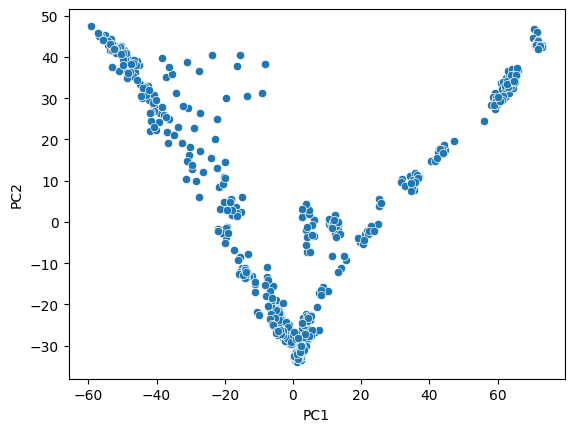

In [ ]:
import seaborn

#Построим график PC1 vs PC2
seaborn.scatterplot(data = principalDf, x="PC1",y="PC2")

<Axes: xlabel='PC3', ylabel='PC4'>

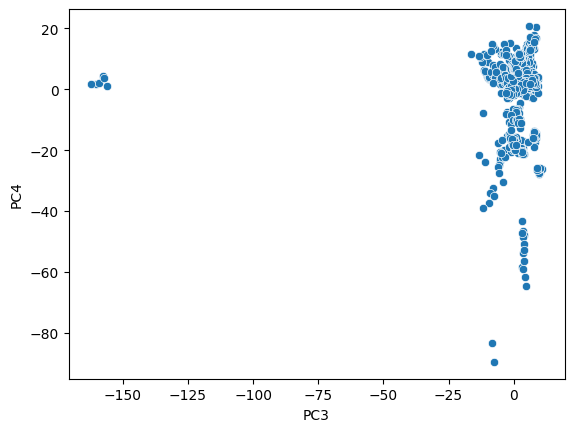

In [ ]:
#Построим график PC3 vs PC4
seaborn.scatterplot(data = principalDf, x="PC3",y="PC4")

Данные выстоились по 3 главной компоненте + часть данных находятся у 4.

<Axes: xlabel='PC5', ylabel='PC6'>

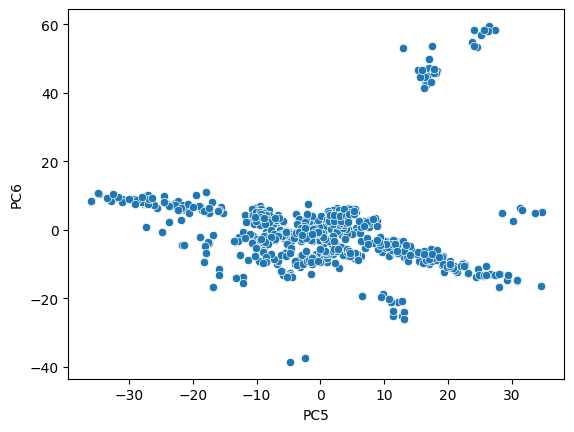

In [ ]:
#Построим график PC5 vs PC6
seaborn.scatterplot(data = principalDf, x="PC5",y="PC6")

Для того, чтобы было понятно какие здесь популяции и как они рассредоточены надо загрузить доп файл txt с названиями популяций. Ниже это делаю.

Посмотрим на долю объяснимой дисперсии каждой из компонент.

In [ ]:
eigenValues = pca.explained_variance_ratio_
explained_variance_ratio = eigenValues / numpy.sum(eigenValues)
explained_variance_ratio

array([0.35185034, 0.24992562, 0.07943861, 0.05883637, 0.05450314,
       0.04898367, 0.04501909, 0.03938137, 0.03709174, 0.03497005])

Первая компонента объясняет 35% вариабильности в данных. Вторая компонента 25%, третья - 8%, четвертая - 6%, пятая - 5% и тд. Компоненты видимо не равнозначны.У первой компонентв наиболее больший эффект

- Вы обнаружили интересный эффект на основании анализа значений 3-ой главной компоненты. Можно ли считать такой результат менее надёжным по сравнению со случаем если бы такой результат получился при анализе значений 1 компоненты? Обоснуйте свой ответ.

Компоненты хорошо объясняют вариабильность данных. Все компоненты важны. Первые компоненты (PC1) они чувствителны к шумам и к признакам, которые как бы самые сильные эффекты имеют.  
Как я поняла, в зависимости от нашей задачи зависит надежность. Здесь у нас данные популяций со всей Африке, а главное именно есть данные Анголы. Так как смысл исследования, смысл статьи был в том, чтобы есть изолированная популяция (Анголы), которая все еще хранит генетический код о *генетической информации о предках квади* (там с языком связано изчезвнушим и родом деятельности собирательство) - то анализ 3 компоненты и 4 нам как раз дает понять, что есть эта изолированная популяция.  
Если у первой главной копоненты было такое же значиние доли объяснимой дисперсии (вариабильности данных), то это говорило бы что данные однородны, а значит менее надежным считать нельзя, наверное джае наоборот более значимый анализ, так как в 1 главную компнонету могли бы попасть просто выбросы.

Чтобы понять какой индивид какой популяции соответствует. Для этого воспользуемся файлом africa_UNPrem_pops.txt, загрузим его и добавим информацию о популяциях к principalDF.

In [ ]:
pop_data = pd.read_csv("/content/drive/MyDrive/Данные для коллаба/africa_UNPrem_pops.txt", names = ['pop_name'])
pop_data

,pop_name
0,AngolaKwisi
1,AngolaHimba
2,AngolaKuvale
3,AngolaKwepe
4,AngolaKwepe
...,...
691,Egyptian
692,JewMoroccan
693,JewLibyan
694,JewLibyan


In [ ]:
#Присоединим pop_data к principalDF

principalPopDataDF = pd.concat([principalDf, pop_data], axis = 1)
principalPopDataDF

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,pop_name
0,-4.106148,-24.434596,6.285530,13.544111,20.464791,-11.301473,-4.312602,1.778225,4.775726,-5.101520,AngolaKwisi
1,-1.211403,-24.878799,4.611147,6.551892,10.990839,-4.127028,1.378399,1.523204,1.852411,-2.904092,AngolaHimba
2,-4.059575,-23.754352,5.216249,9.671454,16.946413,-7.185368,-2.741616,0.267852,2.050782,-2.791144,AngolaKuvale
3,-7.510797,-11.001549,7.480670,7.576266,17.383087,-5.681037,3.693406,0.048644,2.362004,-9.140417,AngolaKwepe
4,-7.568716,-13.346330,6.646697,7.225777,18.314161,-7.945081,2.292820,1.807632,2.714521,-8.279841,AngolaKwepe
...,...,...,...,...,...,...,...,...,...,...,...
691,65.434267,35.720917,0.891950,6.761697,4.333146,3.255334,4.267322,1.833188,-4.909547,4.153818,Egyptian
692,72.376300,42.864766,2.160605,10.589262,4.497045,4.690953,1.939013,6.392775,-4.041670,2.183711,JewMoroccan
693,72.369416,42.562396,2.351394,10.775999,5.208020,4.521441,1.911242,6.663473,-5.693315,4.406500,JewLibyan
694,71.800543,41.840216,2.108206,11.548246,5.237757,5.443630,2.158593,7.403850,-5.436350,3.763634,JewLibyan


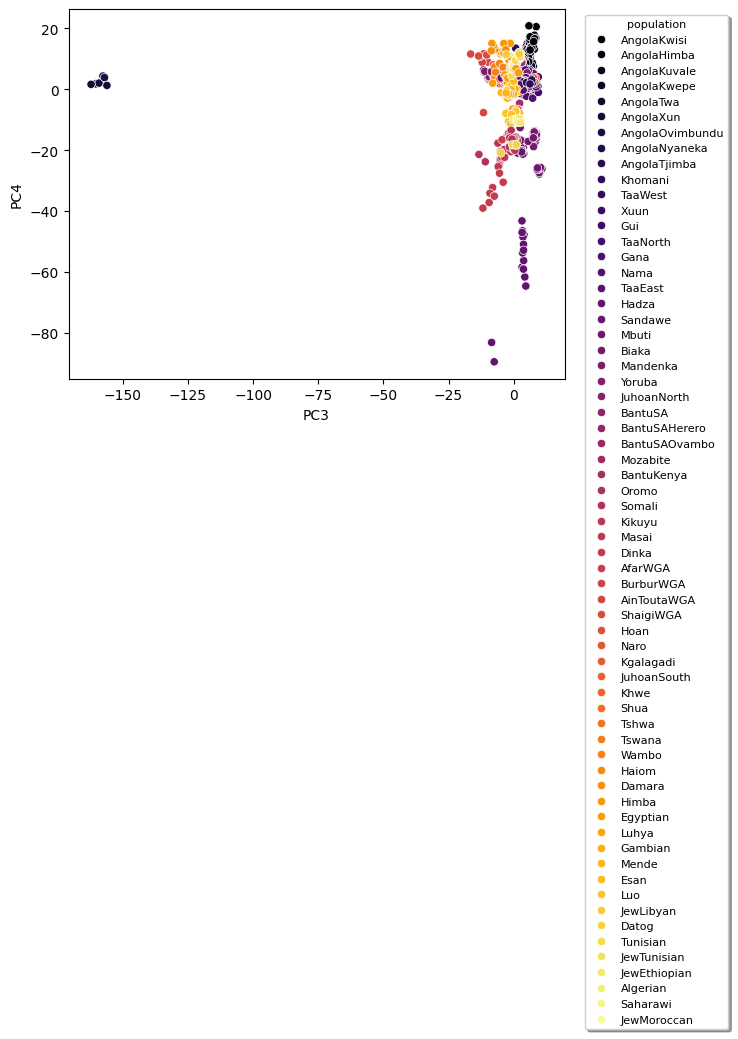

In [ ]:
scatter = seaborn.scatterplot(data=principalPopDataDF, x="PC3", y="PC4", hue="pop_name",  palette='inferno')
scatter.legend(fontsize = 8, \
               bbox_to_anchor= (1.03, 1), \
               title="population", \
               title_fontsize = 8, \
               shadow = True, \
               facecolor = 'white');

Видим что популяции Анголы (AngolaTwa, AngolaXun, AngolaOvimbundu тд.)  находится в отдельном кластере. Видимо это популяции, которые изолированы от других популяций. Также опуляция фиолетового цвета (часть нее), отдельна от других - справа внизу. Тоже фиолетовые точки справа книзу - возможно аутлайеры.  
Также видим что многие (почти все) образцы выстроились по 3 компоненте.

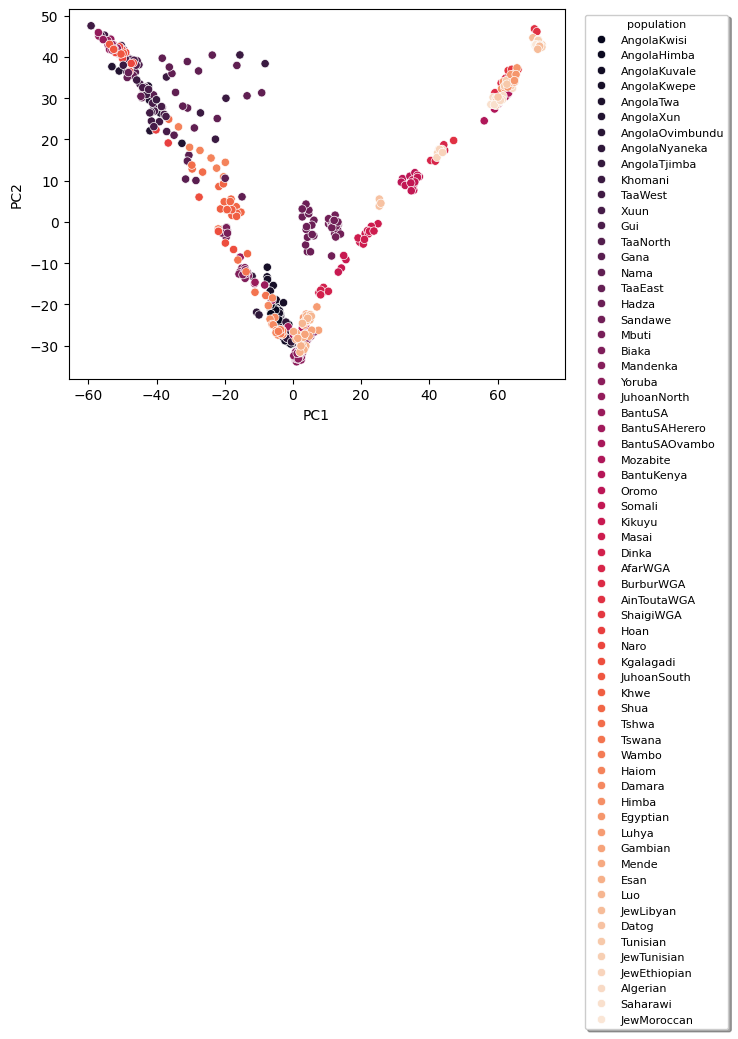

In [ ]:
scatter = seaborn.scatterplot(data=principalPopDataDF, x="PC1", y="PC2", hue="pop_name", palette='rocket')
scatter.legend(fontsize = 8, \
               bbox_to_anchor= (1.03, 1), \
               title="population", \
               title_fontsize = 8, \
               shadow = True, \
               facecolor = 'white');

  Но график похож на букву "V". Можно сказать поппуляции разделились на две части, какие то находятся у компонеты 1 какие то у 2. Видим, что какие то популяции пересекаются, какие то групками находятся в одной части - опосредованно от других популяций. Т.е. есть популяции которые мигрируют между собой, а есть которые нет. Важно обратить внимание на популяцию (черные точки) Анголы, которая сосредоточена ближе к "0" 1 компоненты, а также сверху слева у 2 комноненты также они находятся - и видно, что не пересекаются там с другими популяциями.  Т.е. с помощью метода PCA мы видим как и потоки миграционные, так и опосредованные популяции.

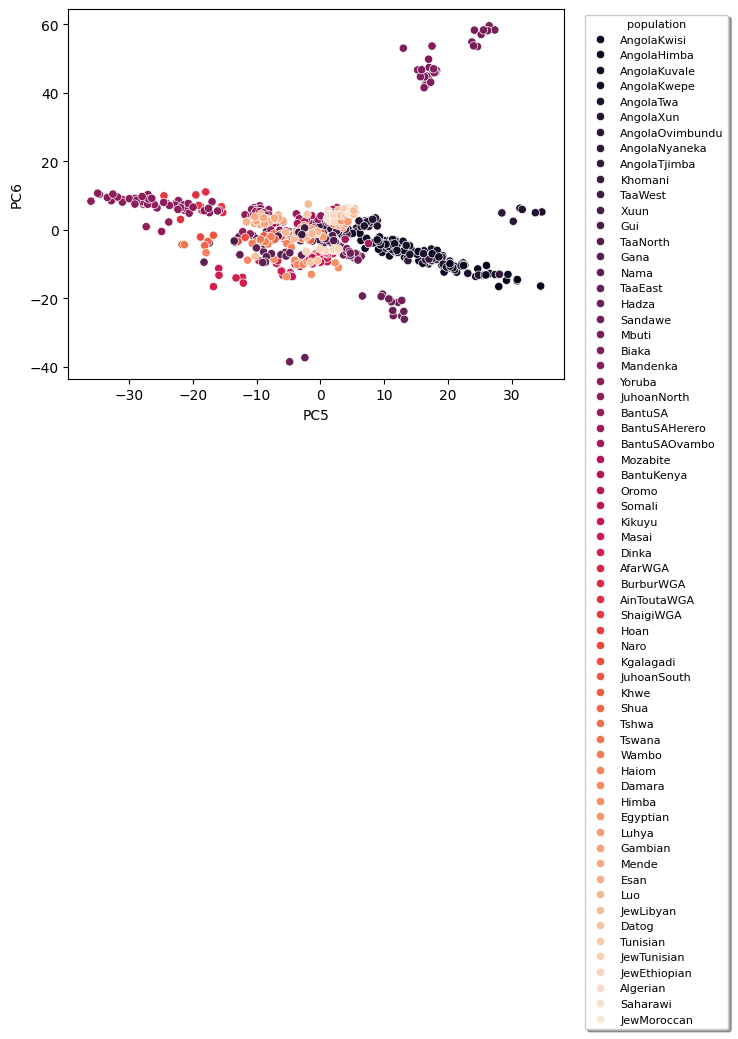

In [ ]:
scatter = seaborn.scatterplot(data=principalPopDataDF, x="PC5", y="PC6", hue="pop_name",  palette='rocket')
scatter.legend(fontsize = 8, \
               bbox_to_anchor= (1.03, 1), \
               title="population", \
               title_fontsize = 8, \
               shadow = True, \
               facecolor = 'white');

На этом графике мы видим, что популяция Анголы сосредоточенна в правой стороне ближе к 5 копмоненте, и видим что эта популяция какбы отделена от других. Также есть популяция (фиолтеовая) которая выстроилась у 6 компонеты - тоже видимо изолированная.А в середине наоборот замечаем что популяции перемешались.

## Иерархическая кластеризация

In [ ]:
import plotly.figure_factory as ff
import numpy as np

fig = ff.create_dendrogram(t_ango_data,labels=ango_data.columns)
fig.update_layout(width=4000, height=450)
fig.show()

Результат полностью соответствует тому что получен с раскрашиванием PCA графика.Видим что есть изолированные популяции. Где как раз на графике ветка с Анголой зеленого цвета.

Т.е главный вывод тут о том, что есть популяция Анголы, которая сохраняет уникальное генетическое наследие.  
Судя по статье, это и хотели исследователи доказать:  
*Принимая во внимание большое разнообразие популяций в Ангольском Намибе, мы выдвигаем гипотезу о том, что сохранившиеся популяции в этом регионе могут сохранять часть генетической информации о предках квади, а также генетические следы исчезнувших популяций собирателей, населявших юго-западную Африку до экспансии банту.*

## Анализ компонент полученного преобразования (доп задание)

Возьмем из дополнительных метаданных - широту и долготу популяций, т.е. их расположение. Но у нас нет данных о каждом индивиде, есть значения для популяций.Надо присвоить в таблице principalPopDataDF - где у нас главные компоненты + названия популяции у каждого индивида - значения широты и долготы из общей таблицы ango_data_meta и afr_data_meta.

In [ ]:
ango_afr_data_meta['Population'].unique()

array(["Ju|'hoan North", "Ju|'hoan South", '!Xun', 'ǂHoan', 'Taa West',
       'Taa North', 'Taa East', 'ǂKhomani', 'Khwe', 'Shua', 'Tshwa',
       'G||ana', 'G|ui', 'Naro', 'Hai||om', 'Nama', 'Damara', 'Herero',
       'Himba', 'Ovambo', 'Tswana', 'Kgalagadi', 'Bantu South Africa',
       'Luhya', 'Bantu Kenya', 'Kikuyu', 'Masai', 'Luo', 'Dinka', 'Datog',
       'Afar', 'Jew Ethiopian', 'Oromo', 'Somali', 'Shaigi', 'Ain Touta',
       'Algerian', 'Mozabite', 'Egyptian', 'Jew Libyan', 'Jew Moroccan',
       'Burbur', 'Jew Tunisian', 'Tunisian', 'Saharawi', 'Hadza',
       'Sandawe', 'Mbuti', 'Biaka', 'Gambian', 'Esan', 'Yoruba',
       'Mandenka', 'Mende', 'Ovimbundu', 'Nyaneka', 'Kuvale', nan,
       'Tjimba', 'Twa', 'Kwisi', 'Kwepe'], dtype=object)

In [ ]:
principalPopDataDF['pop_name'].unique()

array(['AngolaKwisi', 'AngolaHimba', 'AngolaKuvale', 'AngolaKwepe',
       'AngolaTwa', 'AngolaXun', 'AngolaOvimbundu', 'AngolaNyaneka',
       'AngolaTjimba', 'Khomani', 'TaaWest', 'Xuun', 'Gui', 'TaaNorth',
       'Gana', 'Nama', 'TaaEast', 'Hadza', 'Sandawe', 'Mbuti', 'Biaka',
       'Mandenka', 'Yoruba', 'JuhoanNorth', 'BantuSA', 'BantuSAHerero',
       'BantuSAOvambo', 'Mozabite', 'BantuKenya', 'Oromo', 'Somali',
       'Kikuyu', 'Masai', 'Dinka', 'AfarWGA', 'BurburWGA', 'AinToutaWGA',
       'ShaigiWGA', 'Hoan', 'Naro', 'Kgalagadi', 'JuhoanSouth', 'Khwe',
       'Shua', 'Tshwa', 'Tswana', 'Wambo', 'Haiom', 'Damara', 'Himba',
       'Egyptian', 'Luhya', 'Gambian', 'Mende', 'Esan', 'Luo',
       'JewLibyan', 'Datog', 'Tunisian', 'JewTunisian', 'JewEthiopian',
       'Algerian', 'Saharawi', 'JewMoroccan'], dtype=object)

Не понимаю, как соеденить такое большое количество популяций со столбцом 'Country' таблицы, полученным из дополнительных материалах статьи метаданные использованных образцов.

Надо понять какие компоненты к каим метаданным лучше соответствуют. Тут есть координаты и языковые группы, есть широта-долгота.

In [ ]:
pop_data_new = pd.read_csv("/content/drive/MyDrive/Данные для коллаба/africa_UNPrem_correspondence_table_pops.txt", sep="\t",  names = ['Population_new', 'pop_name'])
pop_data_new.tail(20)

,Population_new,pop_name
44,Tshwa,Tshwa
45,Tswana,Tswana
46,Wambo,NaN
47,Haiom,Hai||om
48,Damara,Damara
49,Himba,Himba
50,Egyptian,NaN
51,Luhya,Luhya
52,Gambian,Gambian
53,Mende,Mende


In [ ]:
pop_data_new['Population_new'].unique()

array(['AngolaKwisi', 'AngolaHimba', 'AngolaKuvale', 'AngolaKwepe',
       'AngolaTwa', 'AngolaXun', 'AngolaOvimbundu', 'AngolaNyaneka',
       'AngolaTjimba', 'Khomani', 'TaaWest', 'Xuun', 'Gui', 'TaaNorth',
       'Gana', 'Nama', 'TaaEast', 'Hadza', 'Sandawe', 'Mbuti', 'Biaka',
       'Mandenka', 'Yoruba', 'JuhoanNorth', 'BantuSA', 'BantuSAHerero',
       'BantuSAOvambo', 'Mozabite', 'BantuKenya', 'Oromo', 'Somali',
       'Kikuyu', 'Masai', 'Dinka', 'AfarWGA', 'BurburWGA', 'AinToutaWGA',
       'ShaigiWGA', 'Hoan', 'Naro', 'Kgalagadi', 'JuhoanSouth', 'Khwe',
       'Shua', 'Tshwa', 'Tswana', 'Wambo', 'Haiom', 'Damara', 'Himba',
       'Egyptian', 'Luhya', 'Gambian', 'Mende', 'Esan', 'Luo',
       'JewLibyan', 'Datog', 'Tunisian', 'JewTunisian', 'JewEthiopian',
       'Algerian', 'Saharawi', 'JewMoroccan'], dtype=object)

In [ ]:
pop_data_new['pop_name'].unique()

array(['Kwisi', 'Himba', 'Kuvale', 'Kwepe', 'Twa', '!Xun', 'Ovimbundu',
       'Nyaneka', 'Tjimba', '?Khomani', 'Taa West', 'G|ui', 'Taa North',
       'G||ana', 'Nama', 'Taa East', 'Hadza', 'Sandawe', 'Mbuti', 'Biaka',
       'Mandenka', 'Yoruba', "Ju|'hoan North", 'Bantu South Africa',
       'Herero', 'Ovambo', 'Mozabite', 'Bantu Kenya', 'Oromo', 'Somali',
       'Kikuyu', 'Masai', 'Dinka', 'Afar', 'Burbur', 'Ain Touta',
       'Shaigi', '?Hoan', 'Naro', 'Kgalagadi', "Ju|'hoan South", 'Khwe',
       'Shua', 'Tshwa', 'Tswana', nan, 'Hai||om', 'Damara', 'Luhya',
       'Gambian', 'Mende', 'Esan', 'Luo', 'Jew Libyan', 'Datog',
       'Tunisian', 'Jew Tunisian', 'Jew Ethiopian', 'Algerian',
       'Saharawi', 'Jew Moroccan'], dtype=object)

Отметим, что есть некоторые популяции потерялись, при соотношении данных, из статьи для которых мы провели PCA и доп. метаданных - просто их не оказалось в доп. данных

Я так и не поняла как быстро заменить названия популяций, поменяю в ручную.

In [ ]:
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Kwisi','AngolaKwisi')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Himba','AngolaHimba')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Kuvale','AngolaKuvale')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Kwepe','AngolaKwepe')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Twa','AngolaTwa')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('!Xun','AngolaXun')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Ovimbundu','AngolaOvimbundu')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Nyaneka','AngolaNyaneka')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Tjimba','AngolaTjimba')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('?Khomani','Khomani')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Taa West','TaaWest')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('G|ui','Gui')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Taa North','TaaNorth')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('G||ana','Gana')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Nama','Nama')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Taa East','TaaEast')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Hadza','Hadza')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Sandawe','Sandawe')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Mbuti','Mbuti')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Biaka','Biaka')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Mandenka','Mandenka')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Yoruba','Yoruba')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Ju|hoan North','JuhoanNorth')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Bantu South Africa','BantuSA')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Herero','BantuSAHerero')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Ovambo','BantuSAOvambo')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Mozabite','Mozabite')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Bantu Kenya','BantuKenya')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Oromo','Oromo')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Somali','Somali')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Kikuyu','Kikuyu')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Masai','Masai')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Dinka','Dinka')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Afar','AfarWGA')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Burbur','BurburWGA')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Ain Touta','AinToutaWGA')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Shaigi','ShaigiWGA')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('?Hoan','Hoan')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Naro','Naro')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Kgalagadi','Kgalagadi')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Ju|hoan South','JuhoanSouth')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Khwe','Khwe')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Shua','Shua')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Tshwa','Tshwa')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Hai||om','Haiom')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Damara','Damara')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Luhya','Luhya')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Gambian','Gambian')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Mende','Mende')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Esan','Esan')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Luo','Luo')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Jew Libyan','JewLibyan')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Datog','Datog')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Tunisian','Tunisian')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Jew Tunisian','JewTunisian')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Jew Ethiopian','JewEthiopian')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Algerian','Algerian')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Saharawi','Saharawi')
ango_afr_data_meta['Population'] = ango_afr_data_meta['Population'].str.replace('Jew Moroccan','JewMoroccan')

In [ ]:
ango_afr_data_meta.isna().sum()

,0
1,
Population,6
Code,6
Language,0
Language group,6
Country,0
Latitude,0
Longitude,0


In [ ]:
ango_afr_data_meta['Population'].unique()

array(["Ju|'hoan North", "Ju|'hoan South", 'AngolaXun', 'ǂHoan',
       'TaaWest', 'TaaNorth', 'TaaEast', 'ǂKhomani', 'Khwe', 'Shua',
       'Tshwa', 'Gana', 'Gui', 'Naro', 'Haiom', 'Nama', 'Damara',
       'BantuSAHerero', 'AngolaHimba', 'BantuSAOvambo', 'Tswana',
       'Kgalagadi', 'BantuSA', 'Luhya', 'BantuKenya', 'Kikuyu', 'Masai',
       'Luo', 'Dinka', 'Datog', 'AfarWGA', 'JewEthiopian', 'Oromo',
       'Somali', 'ShaigiWGA', 'AinToutaWGA', 'Algerian', 'Mozabite',
       'Egyptian', 'JewLibyan', 'JewMoroccan', 'BurburWGA', 'JewTunisian',
       'Tunisian', 'Saharawi', 'Hadza', 'Sandawe', 'Mbuti', 'Biaka',
       'Gambian', 'Esan', 'Yoruba', 'Mandenka', 'Mende',
       'AngolaOvimbundu', 'AngolaNyaneka', 'AngolaKuvale', nan,
       'AngolaTjimba', 'AngolaTwa', 'AngolaKwisi', 'AngolaKwepe'],
      dtype=object)

In [ ]:
principalPopDataDF['pop_name'].unique()

array(['AngolaKwisi', 'AngolaHimba', 'AngolaKuvale', 'AngolaKwepe',
       'AngolaTwa', 'AngolaXun', 'AngolaOvimbundu', 'AngolaNyaneka',
       'AngolaTjimba', 'Khomani', 'TaaWest', 'Xuun', 'Gui', 'TaaNorth',
       'Gana', 'Nama', 'TaaEast', 'Hadza', 'Sandawe', 'Mbuti', 'Biaka',
       'Mandenka', 'Yoruba', 'JuhoanNorth', 'BantuSA', 'BantuSAHerero',
       'BantuSAOvambo', 'Mozabite', 'BantuKenya', 'Oromo', 'Somali',
       'Kikuyu', 'Masai', 'Dinka', 'AfarWGA', 'BurburWGA', 'AinToutaWGA',
       'ShaigiWGA', 'Hoan', 'Naro', 'Kgalagadi', 'JuhoanSouth', 'Khwe',
       'Shua', 'Tshwa', 'Tswana', 'Wambo', 'Haiom', 'Damara', 'Himba',
       'Egyptian', 'Luhya', 'Gambian', 'Mende', 'Esan', 'Luo',
       'JewLibyan', 'Datog', 'Tunisian', 'JewTunisian', 'JewEthiopian',
       'Algerian', 'Saharawi', 'JewMoroccan'], dtype=object)

In [ ]:
principalPopDataDF.isna().sum()

,0
PC1,0
PC2,0
PC3,0
PC4,0
PC5,0
PC6,0
PC7,0
PC8,0
PC9,0
PC10,0


In [ ]:
ango_afr_data_meta.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69 entries, 0 to 14
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Population      63 non-null     object
 1   Code            63 non-null     object
 2   Language        69 non-null     object
 3   Language group  63 non-null     object
 4   Country         69 non-null     object
 5   Latitude        69 non-null     object
 6   Longitude       69 non-null     object
dtypes: object(7)
memory usage: 6.4+ KB


In [ ]:
principalPopDataDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   PC1       696 non-null    float64
 1   PC2       696 non-null    float64
 2   PC3       696 non-null    float64
 3   PC4       696 non-null    float64
 4   PC5       696 non-null    float64
 5   PC6       696 non-null    float64
 6   PC7       696 non-null    float64
 7   PC8       696 non-null    float64
 8   PC9       696 non-null    float64
 9   PC10      696 non-null    float64
 10  pop_name  696 non-null    object 
dtypes: float64(10), object(1)
memory usage: 59.9+ KB


In [ ]:
principalPopDataDF.rename(columns={"pop_name":"Population"}, inplace=True)

In [ ]:
result = pd.merge(principalPopDataDF, ango_afr_data_meta, on='Population', how='outer')

In [ ]:
result

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Population,Code,Language,Language group,Country,Latitude,Longitude
0,44.033185,17.385202,-2.606987,-15.439868,-3.024099,-7.387813,-3.166845,-18.844367,10.424802,-3.734661,AfarWGA,-,2,Afro-Asiatic,Ethiopia,11.8,41.4
1,40.427576,14.875443,-1.026100,-16.228194,-2.056194,-8.736476,0.409441,-18.972394,8.878614,-1.156139,AfarWGA,-,2,Afro-Asiatic,Ethiopia,11.8,41.4
2,44.500103,17.338265,-2.010892,-14.526298,-2.775536,-8.310192,-1.470222,-18.055464,9.482805,-4.335473,AfarWGA,-,2,Afro-Asiatic,Ethiopia,11.8,41.4
3,41.755659,14.705809,-1.412074,-15.023327,-2.738795,-7.835252,-0.628185,-20.787422,8.245488,-4.966562,AfarWGA,-,2,Afro-Asiatic,Ethiopia,11.8,41.4
4,44.246017,18.676884,-4.477926,-16.613741,-6.687572,-9.142436,-9.319120,-21.782953,14.090560,-4.811809,AfarWGA,-,2,Afro-Asiatic,Ethiopia,11.8,41.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,Angola,-15.76,12.95
751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,Angola,-16.69,12.85
752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,Angola,-16.65,13.44
753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,Angola,-15.72,12.95


In [ ]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PC1             745 non-null    float64
 1   PC2             745 non-null    float64
 2   PC3             745 non-null    float64
 3   PC4             745 non-null    float64
 4   PC5             745 non-null    float64
 5   PC6             745 non-null    float64
 6   PC7             745 non-null    float64
 7   PC8             745 non-null    float64
 8   PC9             745 non-null    float64
 9   PC10            745 non-null    float64
 10  Population      749 non-null    object 
 11  Code            688 non-null    object 
 12  Language        694 non-null    object 
 13  Language group  688 non-null    object 
 14  Country         694 non-null    object 
 15  Latitude        694 non-null    object 
 16  Longitude       694 non-null    object 
dtypes: float64(10), object(7)
memory us

In [ ]:
result.isna().sum()

,0
PC1,10
PC2,10
PC3,10
PC4,10
PC5,10
PC6,10
PC7,10
PC8,10
PC9,10
PC10,10


In [ ]:
 result.dropna(inplace=True)

In [ ]:
result.isna().sum()

,0
PC1,0
PC2,0
PC3,0
PC4,0
PC5,0
PC6,0
PC7,0
PC8,0
PC9,0
PC10,0


Удалили пустые значения для которых не нашлись популяции.

- Подсчитайте корреляции между значениями главных компонент и значениями метапараметров.

In [ ]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 684 entries, 0 to 746
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PC1             684 non-null    float64
 1   PC2             684 non-null    float64
 2   PC3             684 non-null    float64
 3   PC4             684 non-null    float64
 4   PC5             684 non-null    float64
 5   PC6             684 non-null    float64
 6   PC7             684 non-null    float64
 7   PC8             684 non-null    float64
 8   PC9             684 non-null    float64
 9   PC10            684 non-null    float64
 10  Population      684 non-null    object 
 11  Code            684 non-null    object 
 12  Language        684 non-null    object 
 13  Language group  684 non-null    object 
 14  Country         684 non-null    object 
 15  Latitude        684 non-null    object 
 16  Longitude       684 non-null    object 
dtypes: float64(10), object(7)
memory usage: 

Для рассчета корреляций надо у Анголы перевести широту и долготу из такого формата "15.31 S" и "13.99 E" - в *Определите, является ли значение отрицательным или положительным. В системе с градусами и минутами с десятыми долями направления «север», «юг», «восток» и «запад» не используются. Вместо них используются положительные или отрицательные числа для определения точки на карте*

Для строr где была "S" у страны Angola (в колонке "Latitude") - нужно сдделать значения широты отрицательными, так как это обозначался S обозначает южную широту, что соответствует отрицательному значению.  
Сделала эо вручную прям в файле до загрузки его в колаб.

In [ ]:
#result['Longitude'] = result['Longitude'].str.replace('E','')
#также вручную убрала "E" из таблицы

In [ ]:
result['Latitude'] = result['Latitude'].astype(float)
result['Longitude'] = result['Longitude'].astype(float)

In [ ]:
result.isna().sum()

,0
PC1,0
PC2,0
PC3,0
PC4,0
PC5,0
PC6,0
PC7,0
PC8,0
PC9,0
PC10,0


In [ ]:
result.loc[result['Country'] == 'Angola']

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Population,Code,Language,Language group,Country,Latitude,Longitude
14,-1.211403,-24.878799,4.611147,6.551892,10.990839,-4.127028,1.378399,1.523204,1.852411,-2.904092,AngolaHimba,HIMA,11,West Bantu,Angola,-16.98,12.58
16,-2.452477,-25.903272,6.317860,11.116242,15.875280,-9.013041,-1.054283,0.330627,5.136615,-5.919559,AngolaHimba,HIMA,11,West Bantu,Angola,-16.98,12.58
18,-3.153774,-26.184874,6.650382,14.077485,21.028169,-11.741714,-4.405147,2.490042,2.437204,-2.985822,AngolaHimba,HIMA,11,West Bantu,Angola,-16.98,12.58
20,-3.776034,-25.181982,5.240615,14.692837,20.943557,-10.657565,-5.576872,1.964717,2.803351,0.804397,AngolaHimba,HIMA,11,West Bantu,Angola,-16.98,12.58
22,-2.436484,-27.225154,5.503846,12.970133,19.237924,-10.024345,-5.202273,1.440652,-0.240004,1.928189,AngolaHimba,HIMA,11,West Bantu,Angola,-16.98,12.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,-42.351312,31.084289,1.703202,2.730544,6.867021,1.046891,18.810068,3.529457,26.820104,18.979910,AngolaXun,XUNA,0,Kx’a,Angola,-16.34,15.99
226,-50.950623,36.564461,-160.379587,1.757525,34.708684,5.143508,16.057513,1.890315,-0.685741,0.244702,AngolaXun,XUNA,0,Kx’a,Angola,-16.34,15.99
228,-53.021045,37.631351,-159.086638,2.007547,31.276627,6.225504,14.302303,2.011187,2.330894,0.886879,AngolaXun,XUNA,0,Kx’a,Angola,-16.34,15.99
230,-41.920590,22.063230,-162.155137,1.595744,33.688854,4.926109,13.486957,-0.747646,-5.635899,-0.950242,AngolaXun,XUNA,0,Kx’a,Angola,-16.34,15.99


— (*) Объясняют ли координаты сбора образца больше 10% дисперсии между индивидами ?
Не смогла ответить на вопрос, так как не получилось удалить дубликаты.

Можно увидеть что большая часть графика PC3 vs PC4 лежит вдоль оси соответствующей PC3.  
Посчитаем корреляцию между географической локацией сбора образцов и PC3.



Значения корреляций были очень маленькие - можно сказать нет корреляции для 3 компоненты.

In [ ]:
result['PC4'].corr(result['Latitude'])

-0.07240812936830492

In [ ]:
result['PC4'].corr(result['Longitude'])

-0.5430223235295674

Наблюдаем коореляцию Аноглы у долготы - зависимость какая то есть.

In [ ]:
result['PC3'].corr(result['Latitude'])

-0.0015157139985555732

In [ ]:
result['PC3'].corr(result['Longitude'])

0.008791097284729179

Для 2 копоненты есть корреляция для долготы.

Так как у нас нет данных для каждого индивида - представим одного индивида который характеризовал одну популяцию, присвоим ему значения какие то главных компонент и одно значеине широты и долготы. Т.е. одну популяцию будет один индивид представлять.

Для этого заменим всю популяцию центроидом.

In [ ]:
result_centr = ango_afr_data_meta[['Population', 'Latitude', 'Longitude']]
result_centr = result_centr.set_index('Population')
#result_centr.index.name = 'Population'
result_centr

1,Latitude,Longitude
Population,,
Ju|'hoan North,-18.937257,21.452448
Ju|'hoan South,-21.151918,20.681539
AngolaXun,-18.69072,19.682631
ǂHoan,-23.998918,23.435117
TaaWest,-23.639938,20.272741
...,...,...
AngolaKwisi,-15.92,12.62
NaN,-15.72,12.95
AngolaKwepe,-15.78,12.11


In [ ]:
result_corr = result.drop(['Code', 'Language', 'Language group', 'Country', 'Latitude', 'Longitude'],
                          axis=1)

In [ ]:
result_corr

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Population
0,44.033185,17.385202,-2.606987,-15.439868,-3.024099,-7.387813,-3.166845,-18.844367,10.424802,-3.734661,AfarWGA
1,40.427576,14.875443,-1.026100,-16.228194,-2.056194,-8.736476,0.409441,-18.972394,8.878614,-1.156139,AfarWGA
2,44.500103,17.338265,-2.010892,-14.526298,-2.775536,-8.310192,-1.470222,-18.055464,9.482805,-4.335473,AfarWGA
3,41.755659,14.705809,-1.412074,-15.023327,-2.738795,-7.835252,-0.628185,-20.787422,8.245488,-4.966562,AfarWGA
4,44.246017,18.676884,-4.477926,-16.613741,-6.687572,-9.142436,-9.319120,-21.782953,14.090560,-4.811809,AfarWGA
...,...,...,...,...,...,...,...,...,...,...,...
742,1.540040,-31.593395,-2.258881,2.864202,-17.531665,6.186185,12.017749,6.896113,0.167713,-3.663673,Yoruba
743,1.784172,-31.293944,-1.667984,3.237903,-15.866434,5.600673,11.988106,5.396541,1.404971,-3.434484,Yoruba
744,1.952124,-31.778594,-5.634055,3.797662,-24.581815,7.941262,10.394884,8.975056,3.330914,-7.597888,Yoruba
745,2.013365,-31.458531,-0.934116,2.726966,-16.117550,5.428416,11.527470,4.996861,1.778656,-2.824607,Yoruba


In [ ]:
duplicates = result_centr.index.duplicated()
print(result_centr[duplicates])

1           Latitude Longitude
Population                    
NaN           -15.76     12.95
AngolaHimba   -16.98     12.58
NaN           -16.69     12.85
NaN           -16.65     13.44
NaN           -15.72     12.95
NaN           -15.99     12.53
AngolaXun     -16.34     15.99


In [ ]:
result_centr = result_centr.drop_duplicates()

In [ ]:
result_centr

1,Latitude,Longitude
Population,,
Ju|'hoan North,-18.937257,21.452448
Ju|'hoan South,-21.151918,20.681539
AngolaXun,-18.69072,19.682631
ǂHoan,-23.998918,23.435117
TaaWest,-23.639938,20.272741
...,...,...
AngolaKwisi,-15.92,12.62
NaN,-15.72,12.95
AngolaKwepe,-15.78,12.11


In [ ]:
duplicates = result_centr.index.duplicated()
print(result_centr[duplicates])

1           Latitude Longitude
Population                    
NaN           -15.76     12.95
AngolaHimba   -16.98     12.58
NaN           -16.69     12.85
NaN           -16.65     13.44
NaN           -15.72     12.95
NaN           -15.99     12.53
AngolaXun     -16.34     15.99


In [ ]:
centroidsDF = result_corr.groupby('Population').mean()
principalCentroidsCoorsDf = pd.concat([centroidsDF, result_centr], axis = 1)

principalCentroidsCoorsDf["PC2"].corr(principalCentroidsCoorsDf['Latitude'])

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

Ругается на дубликаты, без понятия почему он их не удалились выше с помощью drop_duplicates.

у 4 главн. комноненты у нас популяции Анголы. У 5 компоненты (там данные растянулись вдоль этой компоненты) есть популяции которые выделяются опосредованно от других, видим тут корреляцию по языкам

In [ ]:
result['PC4'].corr(result['Language'])

0.08191630094208466

In [ ]:
result['PC5'].corr(result['Language'])

-0.509477794561802